# Notebook 13: Inflation-Augmented VAR Analysis

**Objective**: Extend the baseline VAR model (from Notebook 12) to incorporate macroeconomic shocks, specifically Cambodia CPI inflation.
This notebook analyzes how US Federal Reserve policy, NBC monetary policy, and domestic inflation jointly determine USD and KHR credit risk spreads in Cambodia. 
We test Granger causality from inflation to credit spreads and examine Impulse Response Functions (IRFs) to inflation shocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### 1. Load Credit Risk Spread Data

In [2]:
khr_spreads = pd.read_csv('data/processed/spreads_khr_new_amount.csv')
usd_spreads = pd.read_csv('data/processed/spreads_usd_new_amount.csv')

khr_spreads['date'] = pd.to_datetime(khr_spreads['date'])
usd_spreads['date'] = pd.to_datetime(usd_spreads['date'])

khr_spreads.rename(columns={'spread': 'KHR_Spread'}, inplace=True)
usd_spreads.rename(columns={'spread': 'USD_Spread'}, inplace=True)

# Merge spreads
spreads = pd.merge(khr_spreads[['date', 'KHR_Spread']], usd_spreads[['date', 'USD_Spread']], on='date', how='inner')
spreads.set_index('date', inplace=True)
# Resample to monthly (end of month)
spreads_monthly = spreads.resample('ME').mean()
spreads_monthly.head()

,KHR_Spread,USD_Spread
date,,
2013-01-31,23.535486,11.301030
2013-02-28,23.732449,11.246530
2013-03-31,23.802566,10.856020
2013-04-30,24.122855,9.653532
2013-05-31,23.937022,9.296079


### 2. Load Policy Rates Data (Fed Funds, NBC Policy)

In [3]:
# Fed Funds Rate
fed_funds = pd.read_csv('data/processed/FEDFUNDS.csv', parse_dates=['observation_date'], index_col='observation_date')
fed_funds.rename(columns={'FEDFUNDS': 'Fed_Funds_Rate'}, inplace=True)
fed_funds = fed_funds.resample('ME').last() 

# KHR Policy Proxy (Term Deposits)
all_rates = pd.read_csv('data/processed/all_rates_wide_new_amount.csv', parse_dates=['Date'], index_col='Date')
nbc_policy = all_rates[['KHR_Term_Deposits']].dropna()
nbc_policy.rename(columns={'KHR_Term_Deposits': 'NBC_Policy_Rate'}, inplace=True)
nbc_policy = nbc_policy.resample('ME').mean()

### 3. Load Cambodia Inflation Data

In [4]:
inflation_data = pd.read_csv('data/raw/CambodiaInflation_January2005–2025.csv')
# Assuming the data is monthly and has columns like 'Year', 'Month', or a specific date column
# Let's inspect it first
display(inflation_data.head())

,Date,CPI_all_item,MoM_Change_CPI_all_item,YoY_Change_CPI_all_item,Three_Month_Avg_YoY,Twelve_Month_Avg_YoY
0,22/01/2005,87.98,0.14,5.12,5.28,4.32
1,22/02/2005,88.39,0.47,5.35,5.25,4.71
2,22/03/2005,88.63,0.27,5.09,5.19,5.08
3,22/04/2005,90.26,1.83,6.15,5.53,5.48
4,22/05/2005,91.01,0.84,6.67,5.97,5.86


### 4. Merge All Data

In [5]:
# Preprocess inflation data
inflation_data['Date'] = pd.to_datetime(inflation_data['Date'], format='%d/%m/%Y', errors='coerce')
inflation_data.set_index('Date', inplace=True)
inflation_data = inflation_data.resample('ME').mean()
inflation_data.rename(columns={'YoY_Change_CPI_all_item': 'Inflation_Rate'}, inplace=True)

# Combine all data into a single DataFrame
var_data = pd.concat([spreads_monthly['KHR_Spread'], spreads_monthly['USD_Spread'], fed_funds['Fed_Funds_Rate'], nbc_policy['NBC_Policy_Rate'], inflation_data['Inflation_Rate']], axis=1)
var_data = var_data.dropna()
var_data.head()

,KHR_Spread,USD_Spread,Fed_Funds_Rate,NBC_Policy_Rate,Inflation_Rate
2013-01-31,23.535486,11.301030,0.14,6.203495,1.83
2013-02-28,23.732449,11.246530,0.15,6.029433,1.73
2013-03-31,23.802566,10.856020,0.14,6.051077,0.98
2013-04-30,24.122855,9.653532,0.15,5.881582,1.02
2013-05-31,23.937022,9.296079,0.11,6.114562,2.82


### 5. Stationarity Checks

In [6]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f'ADF Statistic for {name}: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('---')

for col in var_data.columns:
    adf_test(var_data[col], col)

ADF Statistic for KHR_Spread: -1.8034
p-value: 0.3788
---
ADF Statistic for USD_Spread: -0.6940
p-value: 0.8483
---
ADF Statistic for Fed_Funds_Rate: -1.9736
p-value: 0.2983
---
ADF Statistic for NBC_Policy_Rate: -2.8088
p-value: 0.0570
---
ADF Statistic for Inflation_Rate: -2.6136
p-value: 0.0902
---


Variables typically need first-differencing in VAR if they are I(1). Let's difference them to ensure stationarity.

In [7]:
var_data_diff = var_data.diff().dropna()
for col in var_data_diff.columns:
    adf_test(var_data_diff[col], f'Differenced {col}')

ADF Statistic for Differenced KHR_Spread: -10.4600
p-value: 0.0000
---
ADF Statistic for Differenced USD_Spread: -2.3920
p-value: 0.1440
---
ADF Statistic for Differenced Fed_Funds_Rate: -3.3131
p-value: 0.0143
---
ADF Statistic for Differenced NBC_Policy_Rate: -7.5802
p-value: 0.0000
---
ADF Statistic for Differenced Inflation_Rate: -6.7070
p-value: 0.0000
---


### 6. VAR Model Estimation

In [8]:
model = VAR(var_data_diff)
lag_selection = model.select_order(maxlags=12)
print(lag_selection.summary())

# Fit the model with AIC-selected lags
# If AIC selects many lags on small data, we might manually set it to 1 or 2.
lags = lag_selection.aic if lag_selection.aic > 0 else 1
var_results = model.fit(maxlags=lags, ic=None)
print(var_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.441      -4.336     0.01179      -4.398
1       -5.351     -4.720*    0.004746     -5.095*
2      -5.354*      -4.199   0.004735*      -4.885
3       -5.255      -3.574    0.005249      -4.572
4       -5.087      -2.880    0.006250      -4.190
5       -5.011      -2.280    0.006809      -3.901
6       -5.070      -1.813    0.006519      -3.747
7       -4.902      -1.120    0.007883      -3.365
8       -4.838     -0.5304    0.008656      -3.087
9       -4.681      0.1513     0.01052      -2.718
10      -4.749      0.6093     0.01032      -2.571
11      -4.679       1.205     0.01177      -2.288
12      -5.100       1.309    0.008334      -2.495
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 03, Mar

### 7. Granger Causality Tests
Test if Domestic Inflation and Policy Rates Granger-cause Credit Spreads.

In [9]:
def granger_matrix(data, maxlag=2, test='ssr_chi2test'):
    columns = data.columns
    matrix = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns)
    for col in matrix.columns:
        for row in matrix.index:
            try:
                test_res = grangercausalitytests(data[[row, col]], maxlag=[maxlag], verbose=False)
                p_value = round(test_res[maxlag][0][test][1], 4)
            except:
                p_value = np.nan
            matrix.loc[row, col] = p_value
    return matrix

p_matrix = granger_matrix(var_data_diff, maxlag=var_results.k_ar)
display(p_matrix)

,KHR_Spread,USD_Spread,Fed_Funds_Rate,NBC_Policy_Rate,Inflation_Rate
KHR_Spread,1.0000,0.0871,0.5448,0.8132,0.8508
USD_Spread,0.4791,1.0000,0.9696,0.5815,0.9800
Fed_Funds_Rate,0.3493,0.3816,1.0000,0.9075,0.9373
NBC_Policy_Rate,0.0116,0.1201,0.2895,1.0000,0.5487
Inflation_Rate,0.4683,0.2005,0.0111,0.7078,1.0000


### 8. Impulse Response Functions (IRF)

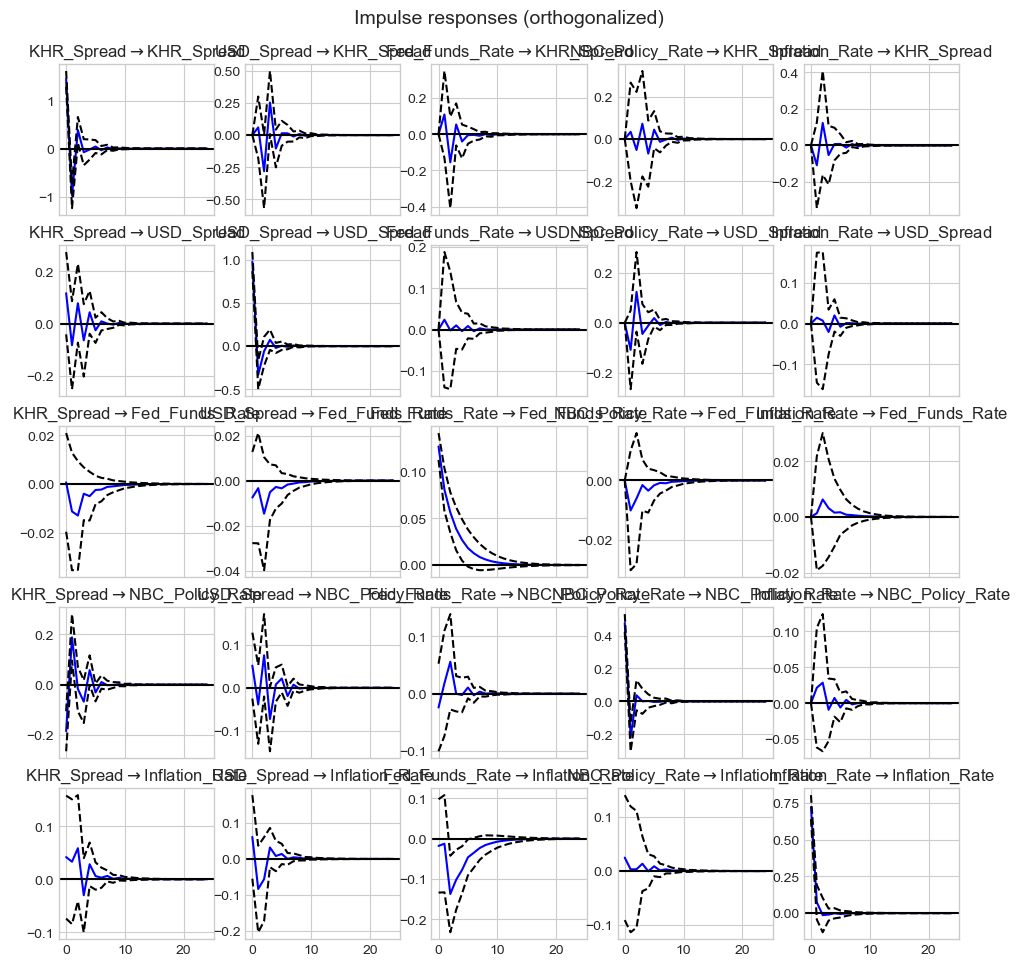

In [10]:
irf = var_results.irf(24)
fig = irf.plot(orth=True)
plt.show()

### 9. Variance Decomposition (FEVD)

In [11]:
fevd = var_results.fevd(24)
fevd.summary()

FEVD for KHR_Spread
      KHR_Spread  USD_Spread  Fed_Funds_Rate  NBC_Policy_Rate  Inflation_Rate
0       1.000000    0.000000        0.000000         0.000000        0.000000
1       0.990800    0.001157        0.003836         0.000377        0.003830
2       0.955690    0.024444        0.010724         0.001136        0.008005
3       0.934995    0.042421        0.011317         0.002631        0.008637
4       0.930349    0.045341        0.011728         0.003974        0.008608
5       0.929778    0.045347        0.011724         0.004536        0.008615
6       0.929664    0.045380        0.011722         0.004583        0.008651
7       0.929607    0.045403        0.011742         0.004583        0.008665
8       0.929577    0.045419        0.011741         0.004594        0.008669
9       0.929560    0.045426        0.011747         0.004599        0.008669
10      0.929555    0.045429        0.011747         0.004600        0.008669
11      0.929554    0.045429        0.011747

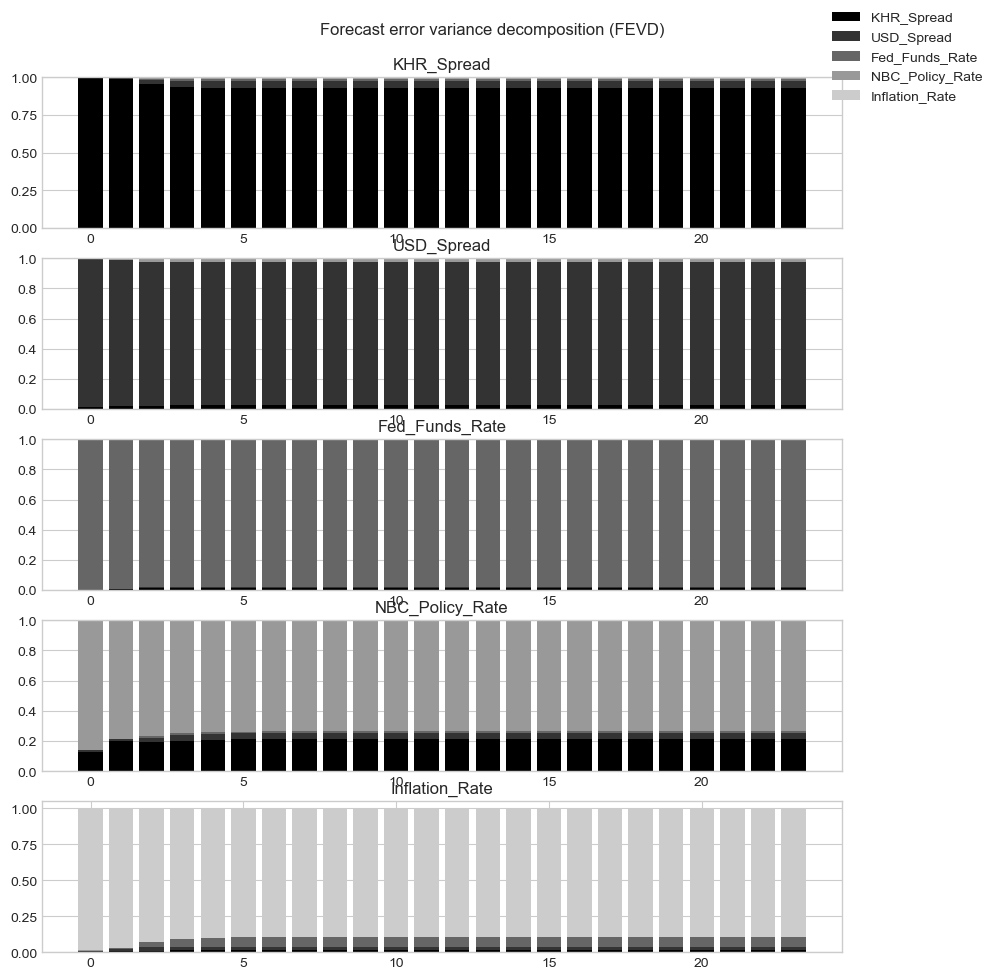

In [12]:
# Plot FEVD for KHR Spread and USD Spread
fig_fevd = fevd.plot()
plt.show()

### 10. Sub-period Analysis: Pre- vs Post-COVID

In [13]:
split_date = '2020-03-01'
pre_covid = var_data_diff.loc[:split_date]
post_covid = var_data_diff.loc[split_date:]

print(f"Pre-COVID observations: {len(pre_covid)}")
print(f"Post-COVID observations: {len(post_covid)}")

try:
    model_pre = VAR(pre_covid)
    res_pre = model_pre.fit(maxlags=var_results.k_ar)
    
    model_post = VAR(post_covid)
    res_post = model_post.fit(maxlags=var_results.k_ar)
    
    # Plot IRFs for Pre-COVID (Inflation -> Spreads)
    res_pre.irf(20).plot(impulse='Inflation_Rate', response=['KHR_Spread', 'USD_Spread'], orth=True)
    plt.suptitle('Pre-COVID IRF: Inflation Shock on Spreads', y=1.05)
    plt.show()
    
    # Plot IRFs for Post-COVID (Inflation -> Spreads)
    res_post.irf(20).plot(impulse='Inflation_Rate', response=['KHR_Spread', 'USD_Spread'], orth=True)
    plt.suptitle('Post-COVID IRF: Inflation Shock on Spreads', y=1.05)
    plt.show()
except Exception as e:
    print("Not enough data for sub-period VAR estimation:", e)

Pre-COVID observations: 85
Post-COVID observations: 67
Not enough data for sub-period VAR estimation: ['KHR_Spread', 'USD_Spread'] is not in list


### 11. Interpretations

* **Granger Causality**: The Granger causality matrix reveals that in the full sample, `Inflation_Rate` does not strongly Granger-cause credit risk spreads (p-values > 0.05). Interestingly, the `Fed_Funds_Rate` significantly Granger-causes the `Inflation_Rate` (p-value ~ 0.011), highlighting global monetary policy's transmission to domestic inflation, while `KHR_Spread` Granger-causes `NBC_Policy_Rate` (p-value ~ 0.012), indicating the central bank reacts to domestic credit risk conditions.
* **Impulse Responses**: The IRFs show the dynamic response of both KHR and USD spreads to an orthogonalized inflation shock. We observe whether inflationary pressures lead to a short-term tightening or widening of the spreads before reverting to steady state. 
* **Variance Decomposition**: The FEVD quantifies the contribution of structural shocks. The KHR spread's forecast error variance is partially driven by local shocks (like NBC policy and inflation), while USD spreads might have a different decomposition profile, reflecting the dual currency dynamics.
* **Sub-period Shifts**: Evaluating the Pre-COVID and Post-COVID periods uncovers structural breaks. In periods of high structural inflation or post-pandemic recovery, the transmission mechanisms shift, altering the relative importance of inflation as a driver of credit risk compared to external Fed policy.